# Predicción de fallas en equipos industriales mediante Aprendizaje de Maquina.
## Proyecto de Aprendizaje automatico.
**Dataset utilizado:** AI4I 2020 Predictive Maintenance Dataset

**Asignatura.** Aprendizaje de Maquina. 

**Integrantes:**
- Javiera Chávez
- Joaquin Olivarez
- Claudio Yañez

---

## Objetivo del proyecto.
El objetivo de este proyecto grupal, es desarrollar y evaluar modelos de aprendizaje automatico que sean capaces de predecir fallas en equipos industriales utilizando el conjunto de datos **AI4I 2020 Predictive Maintenance Dataset**. Se realizará un análisis exploratorio de los datos, un preprocesamiento y preparación de la información, la construcción y evaluación de distintos modelos de Machine Learning y Deep Learning, y la interpretación de los resultados mediante técnicas de explicabilidad como SHAP.

Este notebook documenta de manera estructurada cada una de las etapas del proyecto, siguiendo una metodología de análisis de datos que permite garantizar la trazabilidad entre los datos, los modelos implementados y los resultados obtenidos.


## 1. Importación de librerias.

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import shap

## 2. Carga del conjunto de datos. 

En esta sección se carga el conjunto de datos AI4I 2020 Predictive Maintenance Dataset y se realiza una primera inspección para verificar que la información se haya importado correctamente. Se muestran las dimensiones del dataset y una vista preliminar de los primeros registros.

In [4]:
# Cargar el dataset
df = pd.read_csv("ai4i2020.csv")

# Mostrar dimensiones
print(f"Número de filas: {df.shape[0]}")
print(f"Número de columnas: {df.shape[1]}")

# Mostrar las primeras filas
display(df.head())

Número de filas: 10000
Número de columnas: 14


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 3. Análisis Exploratorio de Datos. 
El análisis exploratorio de datos nos permite comprender la estructura del conjunto de datos antes de aplicar las técnicas de aprendizaje automático. En esta etapa analizamos la información disponible, los tipos de datos, la calidad del dataset, las distribuciones de las variables y posibles patrones relevantes que puedan influir en el desempeño de los modelos.

### 3.1 Informacion General. 

Revisamos la estructura general del conjunto de datos para conocer el número de registros, los tipos de datos y el uso de memoria.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

### 3.2 Estadísticas descriptivas

Calculamos estadísticas descriptivas para las variables numéricas con el fin de conocer su distribución, tendencia central y dispersión.

In [6]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
UDI,10000.0,5000.50000,2886.895680,1.0,2500.75,5000.5,7500.25,10000.0
Air temperature [K],10000.0,300.00493,2.000259,295.3,298.30,300.1,301.50,304.5
Process temperature [K],10000.0,310.00556,1.483734,305.7,308.80,310.1,311.10,313.8
Rotational speed [rpm],10000.0,1538.77610,179.284096,1168.0,1423.00,1503.0,1612.00,2886.0
Torque [Nm],10000.0,39.98691,9.968934,3.8,33.20,40.1,46.80,76.6
Tool wear [min],10000.0,107.95100,63.654147,0.0,53.00,108.0,162.00,253.0
Machine failure,10000.0,0.03390,0.180981,0.0,0.00,0.0,0.00,1.0
TWF,10000.0,0.00460,0.067671,0.0,0.00,0.0,0.00,1.0
HDF,10000.0,0.01150,0.106625,0.0,0.00,0.0,0.00,1.0
PWF,10000.0,0.00950,0.097009,0.0,0.00,0.0,0.00,1.0


**Interpretación**

Las variables numéricas presentan diferentes escalas de medición. Las temperaturas muestran una baja variabilidad, mientras que variables como la velocidad de rotación y el desgaste de la herramienta presentan una mayor dispersión. La variable objetivo *Machine failure* corresponde a una variable binaria, donde predominan los registros sin falla.

### 3.3 Completitud de los datos

verificamos la existencia de valores nulos y registros duplicados para evaluar la calidad inicial del conjunto de datos.

In [8]:
# Valores nulos
nulls = pd.DataFrame({
    "Valores nulos": df.isnull().sum(),
    "Porcentaje (%)": (df.isnull().mean()*100).round(2)
})

display(nulls)

# Duplicados
print(f"Registros duplicados: {df.duplicated().sum()}")

,Valores nulos,Porcentaje (%)
UDI,0,0.0
Product ID,0,0.0
Type,0,0.0
Air temperature [K],0,0.0
Process temperature [K],0,0.0
Rotational speed [rpm],0,0.0
Torque [Nm],0,0.0
Tool wear [min],0,0.0
Machine failure,0,0.0
TWF,0,0.0


Registros duplicados: 0


### 3.4 Distribución de las variables numéricas

Analizamos la distribución de las variables numéricas mediante histogramas con el objetivo de identificar la forma de la distribución, posibles asimetrías y concentraciones de valores que puedan influir en el entrenamiento de los modelos.

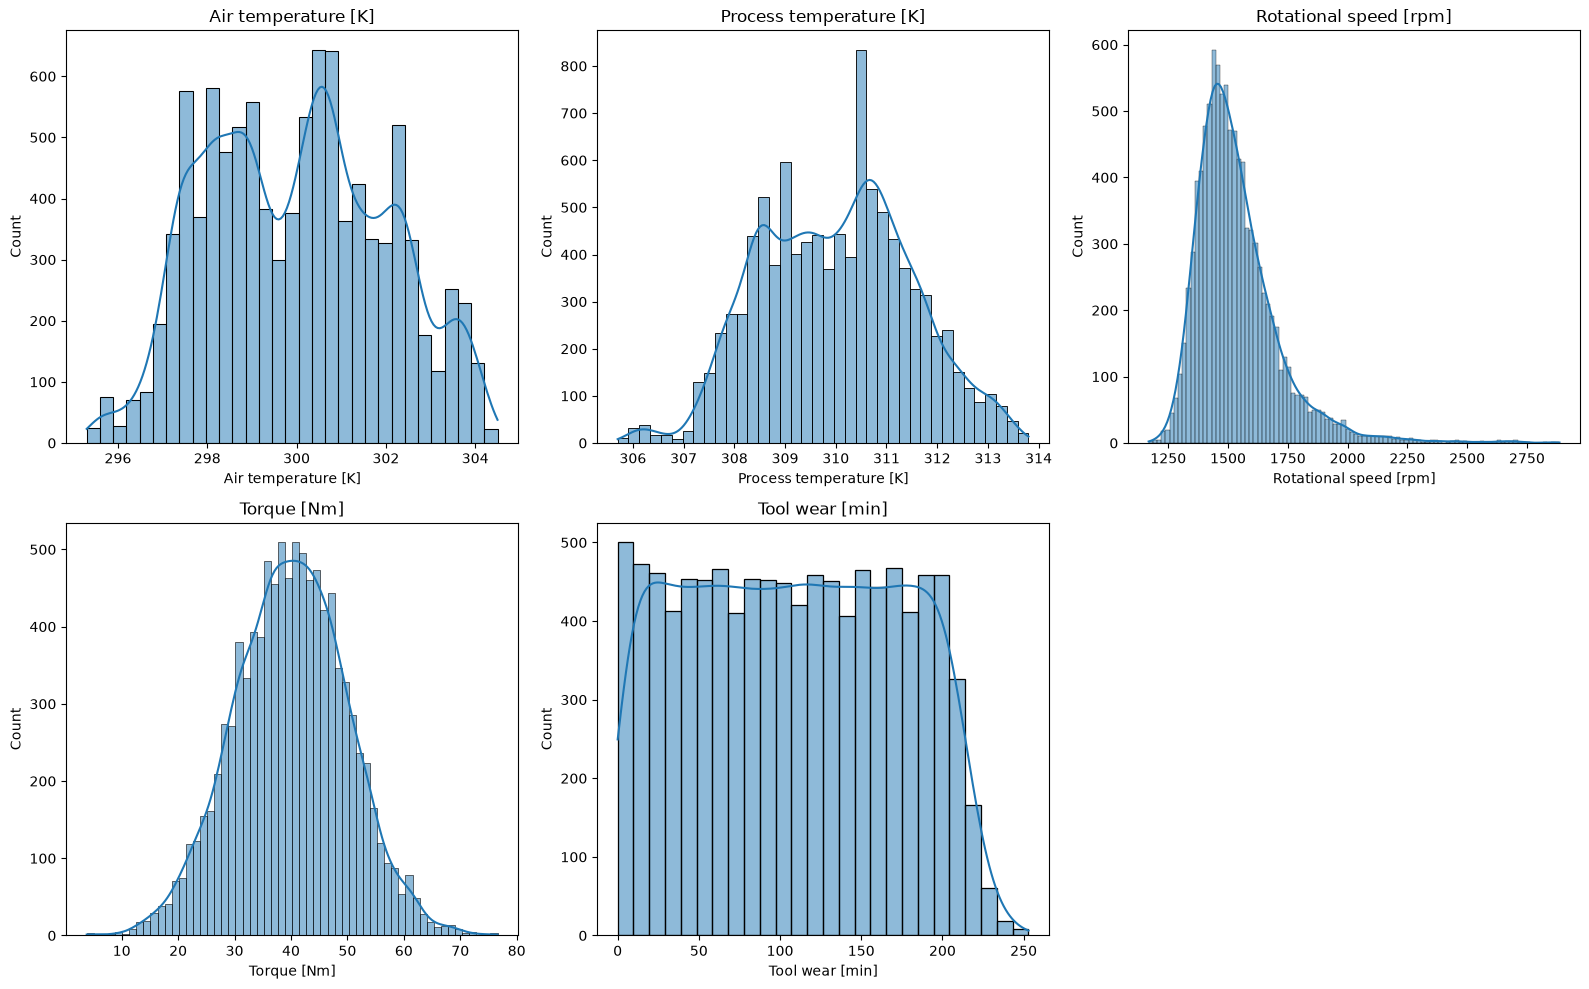

In [10]:
# Variables numéricas que serán analizadas mediante histogramas
variables_numericas = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

# Crear la figura donde se mostrarán los histogramas
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

# Generar un histograma para cada variable numérica
for i, columna in enumerate(variables_numericas):
    sns.histplot(data=df, x=columna, kde=True, ax=axes[i])
    axes[i].set_title(columna)

# Ocultar el último espacio vacío
axes[-1].axis("off")

# Ajustar el diseño y mostrar la figura
plt.tight_layout()
plt.show()

**Interpretación**

Los histogramas muestran que las variables del dataset presentan distribuciones distintas según su naturaleza. Mientras la temperatura del aire y el torque exhiben distribuciones cercanas a una normal, la velocidad de rotación presenta una asimetría positiva, indicando la existencia de un menor número de observaciones con velocidades elevadas. Por otra parte, el desgaste de herramienta presenta una distribución más uniforme, característica consistente con un conjunto de datos generado de manera controlada para representar distintos estados operacionales de los equipos.

### 3.5 Detección de valores atípicos (Outliers)

Los diagramas de caja (boxplots) permiten identificar la presencia de valores atípicos en las variables numéricas del conjunto de datos. Este análisis nos resulta importante porque valores extremos pueden influir en el entrenamiento y desempeño de algunos algoritmos de aprendizaje automático.

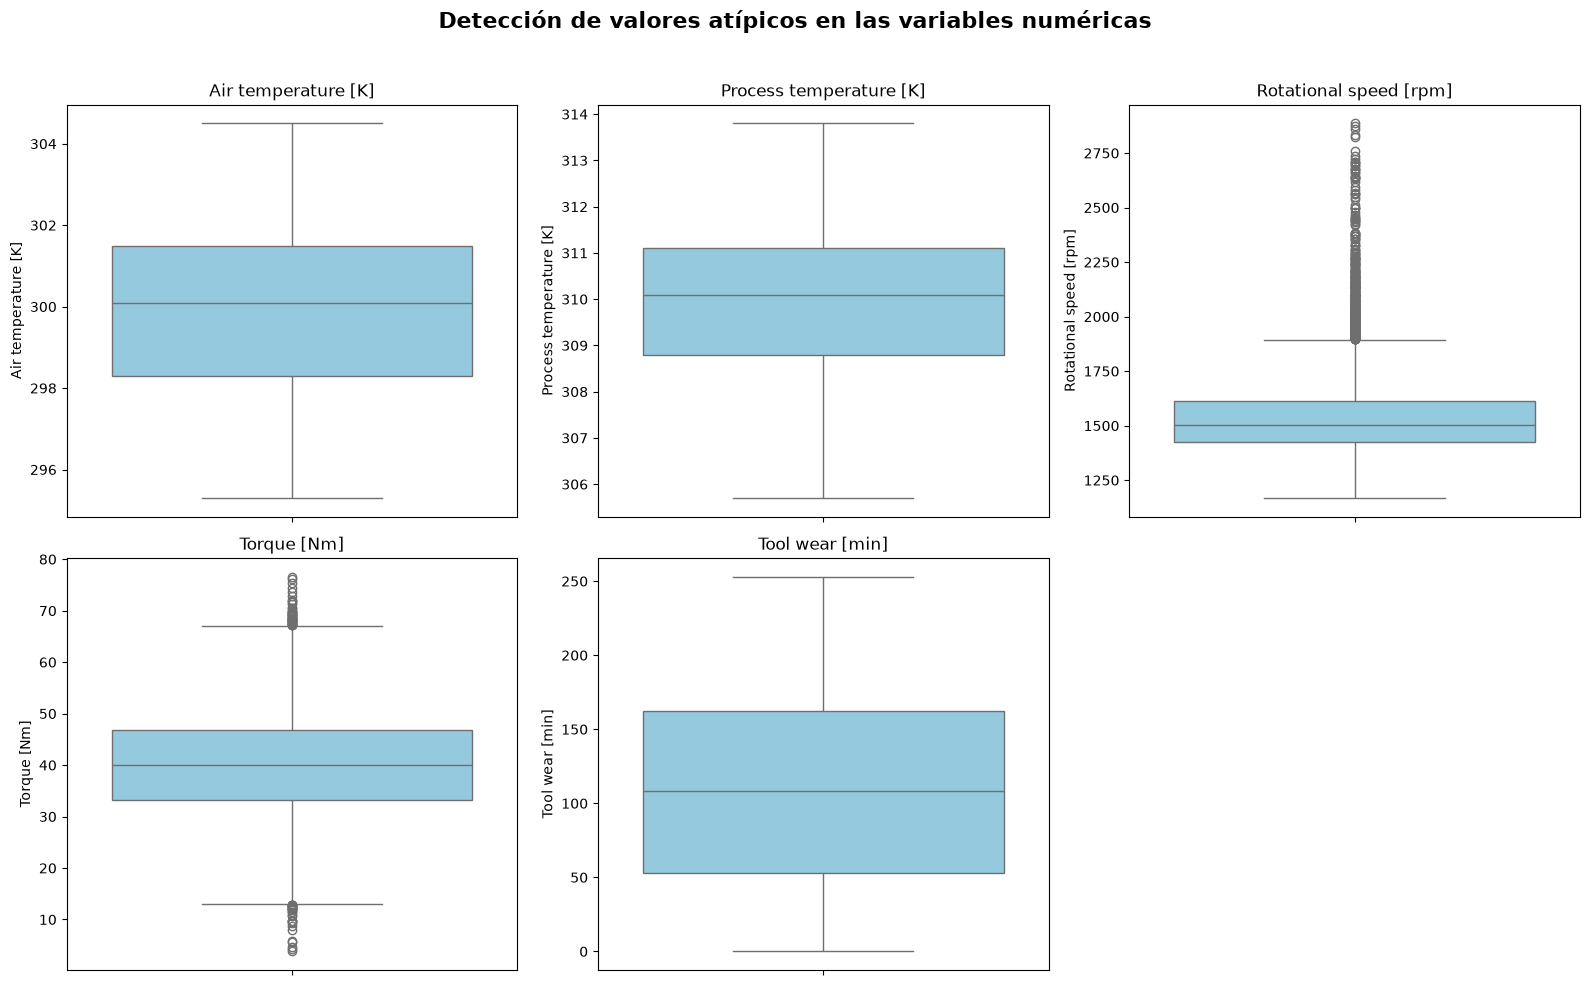

In [11]:
# Variables numéricas que serán evaluadas mediante diagramas de caja
variables_numericas = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

# Crear la figura donde se mostrarán los boxplots
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

# Generar un boxplot para cada variable numérica
for i, columna in enumerate(variables_numericas):

    sns.boxplot(
        data=df,
        y=columna,
        ax=axes[i],
        color="skyblue"
    )

    axes[i].set_title(columna)

# Ocultar el último espacio vacío
axes[-1].axis("off")

# Agregar un título general
plt.suptitle(
    "Detección de valores atípicos en las variables numéricas",
    fontsize=16,
    fontweight="bold"
)

# Ajustar el diseño de la figura
plt.tight_layout(rect=[0, 0, 1, 0.96])

# Mostrar los gráficos
plt.show()

**Interpretación**

Los diagramas de caja muestran que las variables **Air temperature [K]**, **Process temperature [K]** y **Tool wear [min]** no presentan valores atípicos relevantes. En cambio, **Rotational speed [rpm]** concentra una cantidad importante de observaciones extremas, principalmente en valores elevados, mientras que **Torque [Nm]** presenta algunos valores atípicos tanto inferiores como superiores.

Debido a que este conjunto de datos corresponde a un problema de mantenimiento predictivo industrial, estos valores extremos podrían representar condiciones reales de operación de las máquinas y no necesariamente errores de medición. Por esta razón, en esta etapa no se eliminarán los valores atípicos, ya que podrían aportar información relevante para el entrenamiento y la capacidad predictiva de los modelos de aprendizaje automático.

### 3.6 Correlación entre variables. 

En esta sección analizamos la relación existente entre las variables numéricas mediante una matriz de correlación de Pearson. Este análisis permite identificar asociaciones lineales entre las características del conjunto de datos y detectar posibles relaciones que puedan ser útiles durante la construcción de los modelos de aprendizaje automático.

La matriz también permite verificar la existencia de variables altamente correlacionadas que puedan aportar información redundante o generar problemas de multicolinealidad.



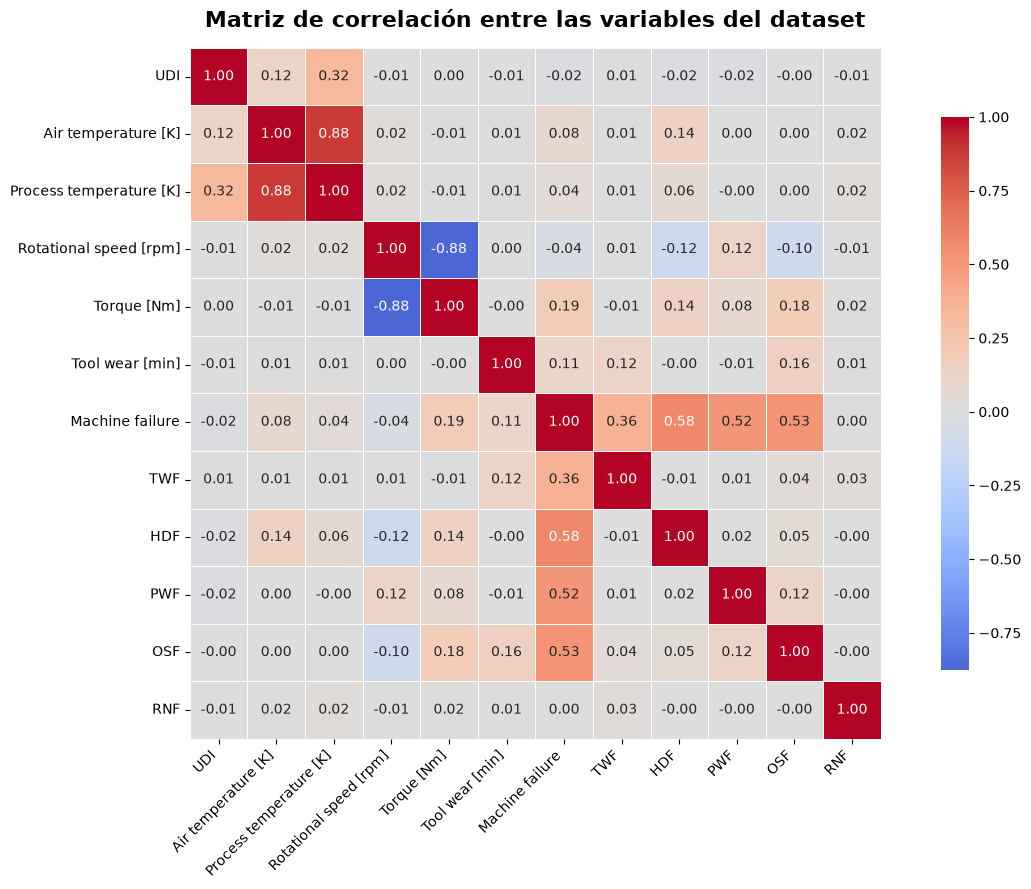

In [13]:
# MATRIZ DE CORRELACIÓN

# Se calcula la correlación de Pearson entre las variables
# numéricas para identificar relaciones lineales y posibles
# dependencias entre ellas.

# Calcular matriz de correlación
corr = df.corr(numeric_only=True)

# Crear figura
plt.figure(figsize=(13,9))

# Dibujar mapa de calor
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink":0.8}
)

# Título
plt.title(
    "Matriz de correlación entre las variables del dataset",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

**Interpretación**

La matriz de correlación nos permite identificar la intensidad de la relación lineal entre las variables numéricas del conjunto de datos.

Se observa una **correlación positiva (0.88)** entre **Air temperature [K]** y **Process temperature [K]**, lo que indica que ambas variables tienden a aumentar conjuntamente durante la operación de las máquinas.

Tambien, existe una **correlación negativa (-0.88)** entre **Rotational speed [rpm]** y **Torque [Nm]**, evidenciando que a mayores velocidades de rotación generalmente se requieren menores niveles de torque.

Respecto a la variable objetivo (**Machine failure**), las correlaciones con las variables operacionales son bajas o moderadas, siendo **Torque [Nm]** y **Tool wear [min]** las que presentan una mayor asociación. Esto sugiere que la ocurrencia de fallas depende de la combinación de múltiples variables y no exclusivamente de una única característica.

Finalmente, las variables **TWF, HDF, PWF, OSF y RNF** presentan correlaciones relativamente altas con **Machine failure**, debido a que representan tipos específicos de fallas. Estas variables serán eliminadas durante el preprocesamiento para evitar fuga de información (*data leakage*) en el entrenamiento de los modelos.

## 4. Calidad de los datos

Antes de construir los modelos de aprendizaje automático es necesario evaluar la calidad del conjunto de datos. En esta etapa se analiza la completitud, consistencia, exactitud y balance de clases del dataset, con el objetivo de determinar si la información disponible es adecuada para el entrenamiento de modelos predictivos y si requiere algún tratamiento previo durante el preprocesamiento.

### 4.1 Completitud

La completitud corresponde a la verificación de registros faltantes y datos duplicados. Un conjunto de datos completo permite entrenar modelos de aprendizaje automático sin introducir sesgos derivados de información incompleta.

In [14]:
# EVALUACIÓN DE COMPLETITUD DEL DATASET

# Se verifica la existencia de valores nulos y registros
# duplicados para determinar si el conjunto de datos requiere
# tareas de imputación o eliminación de observaciones.

# Valores faltantes
print("Valores nulos por columna")
display(df.isnull().sum())

# Registros duplicados
duplicados = df.duplicated().sum()

print(f"\nRegistros duplicados: {duplicados}")

Valores nulos por columna


UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64


Registros duplicados: 0


**Interpretación**

El conjunto de datos no presenta valores nulos ni registros duplicados. Esto indica que la información disponible es completa y no requiere procedimientos de imputación ni eliminación de observaciones antes del entrenamiento de los modelos de aprendizaje automático.

### 4.2 Consistencia de los datos

La consistencia de los datos nos permite verificar que las variables del conjunto de datos sean coherentes con el problema estudiado y mantengan el tipo de información esperado. Revisamos los tipos de datos de cada variable y sus rangos de valores, evaluando que no existan registros físicamente imposibles o inconsistentes.

In [15]:
# CONSISTENCIA DEL DATASET

# Se revisan los tipos de datos y los rangos mínimos y
# máximos de cada variable para verificar que los valores
# sean coherentes con el contexto del mantenimiento
# predictivo industrial.

# Tipos de datos
print("Tipos de datos")
display(df.dtypes)

# Rangos de las variables numéricas
rangos = pd.DataFrame({
    "Mínimo": df.min(numeric_only=True),
    "Máximo": df.max(numeric_only=True)
})

print("\nRangos de las variables numéricas")
display(rangos)

Tipos de datos


UDI                          int64
Product ID                     str
Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object


Rangos de las variables numéricas


,Mínimo,Máximo
UDI,1.0,10000.0
Air temperature [K],295.3,304.5
Process temperature [K],305.7,313.8
Rotational speed [rpm],1168.0,2886.0
Torque [Nm],3.8,76.6
Tool wear [min],0.0,253.0
Machine failure,0.0,1.0
TWF,0.0,1.0
HDF,0.0,1.0
PWF,0.0,1.0


**Interpretación**
Los tipos de datos asignados a cada variable son coherentes con la naturaleza de la información almacenada. Las variables de temperatura y torque corresponden a datos continuos (`float64`), mientras que la velocidad de rotación, el desgaste de herramienta y las variables indicadoras de falla se almacenan como valores enteros (`int64`). Por su parte, las variables **Product ID** y **Type** se representan mediante cadenas de texto (`str`), ya que corresponden a identificadores y categorías, respectivamente.

Al analizar los rangos de las variables numéricas, se observa que todas presentan valores consistentes con el contexto del mantenimiento predictivo industrial. Las temperaturas se encuentran dentro de intervalos esperados, la velocidad de rotación y el torque no presentan valores físicamente imposibles y el desgaste de herramienta comienza en cero, aumentando hasta un máximo de 253 minutos.

Finalmente, las variables binarias (**Machine failure**, **TWF**, **HDF**, **PWF**, **OSF** y **RNF**) contienen únicamente los valores 0 y 1, confirmando que fueron registradas correctamente y no presentan categorías inválidas. En conjunto, estos resultados indican que el dataset posee una adecuada consistencia para continuar con las etapas de preprocesamiento y entrenamiento de los modelos de aprendizaje automático.

### 4.3 Exactitud de los datos

La exactitud de los datos corresponde a la verificación de que los valores registrados sean válidos y representen correctamente el fenómeno estudiado. En esta etapa se revisa que las variables numéricas no contengan valores físicamente imposibles y que las variables categóricas presenten únicamente las categorías definidas para el conjunto de datos.

In [16]:
# EXACTITUD DEL DATASET

# Se verifica que las variables numéricas no presenten
# valores negativos y que la variable categórica "Type"
# contenga únicamente las categorías esperadas.

print("Verificación de valores negativos")

print(f"Air temperature [K]: {(df['Air temperature [K]'] < 0).sum()}")
print(f"Process temperature [K]: {(df['Process temperature [K]'] < 0).sum()}")
print(f"Rotational speed [rpm]: {(df['Rotational speed [rpm]'] < 0).sum()}")
print(f"Torque [Nm]: {(df['Torque [Nm]'] < 0).sum()}")
print(f"Tool wear [min]: {(df['Tool wear [min]'] < 0).sum()}")

print("\nCategorías presentes en la variable Type")

display(pd.DataFrame({
    "Categoría": sorted(df["Type"].unique())
}))

Verificación de valores negativos
Air temperature [K]: 0
Process temperature [K]: 0
Rotational speed [rpm]: 0
Torque [Nm]: 0
Tool wear [min]: 0

Categorías presentes en la variable Type


,Categoría
0,H
1,L
2,M


***Interpretación***

La verificación de exactitud muestra que ninguna de las variables numéricas presenta valores negativos, esto es coherente con la naturaleza de las mediciones registradas. Variables como la temperatura, la velocidad de rotación, el torque y el desgaste de herramienta corresponden a magnitudes físicas que, en este contexto, no deberían asumir valores inferiores a cero.

Asimismo, la variable categórica **Type** contiene únicamente las categorías **H**, **L** y **M**, correspondientes a los tres niveles de calidad definidos para los productos del dataset. No se identifican categorías adicionales o registros inconsistentes.

En consecuencia, no se observan evidencias de errores de captura ni valores inválidos que puedan afectar el entrenamiento de los modelos de aprendizaje automático, por lo que el conjunto de datos presenta un adecuado nivel de exactitud.

### 4.4 Balance de clases

El balance de clases corresponde a la distribución de las observaciones pertenecientes a cada categoría de la variable objetivo. Analizar esta distribución es fundamental en problemas de clasificación, ya que un conjunto de datos altamente desbalanceado puede provocar que los modelos favorezcan la clase mayoritaria, reduciendo su capacidad para detectar correctamente los casos menos frecuentes.

,Cantidad,Porcentaje (%)
Sin falla,9661,96.61
Con falla,339,3.39


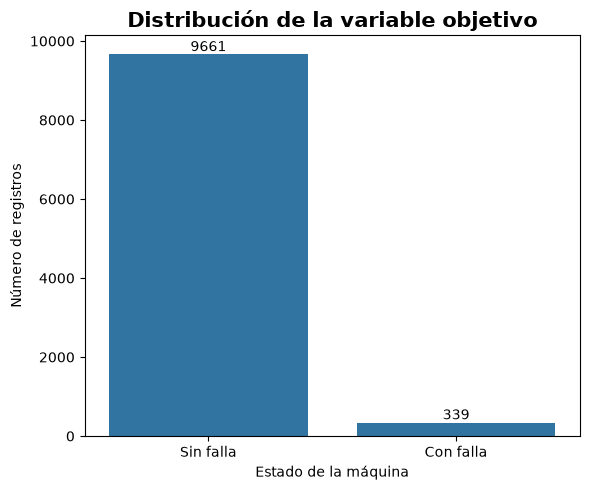

In [20]:
# BALANCE DE CLASES

# Se analiza la distribución de la variable objetivo
# "Machine failure" para determinar si existe desbalance
# entre las clases antes del entrenamiento de los modelos.

# Frecuencia absoluta
conteo = df["Machine failure"].value_counts().sort_index()

# Frecuencia porcentual
porcentaje = (conteo / len(df) * 100).round(2)

# Crear tabla resumen
balance = pd.DataFrame({
    "Cantidad": conteo.values,
    "Porcentaje (%)": (conteo/len(df)*100).round(2).values
},
index=["Sin falla", "Con falla"])

display(balance)

# Gráfico de distribución de clases

plt.figure(figsize=(6,5))

ax = sns.countplot(
    x=df["Machine failure"].map({
        0: "Sin falla",
        1: "Con falla"
    })
)

plt.xlabel("")

plt.title(
    "Distribución de la variable objetivo",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Estado de la máquina")
plt.ylabel("Número de registros")

# Mostrar cantidad sobre cada barra
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

**Interpretación**

La variable objetivo presenta un marcado desbalance entre sus clases. Del total de **10.000 registros**, **9.661 (96,61%)** corresponden a máquinas que no presentan fallas, mientras que solo **339 registros (3,39%)** representan casos de falla.

Esta distribución evidencia un problema de clasificación desbalanceada, ya que los ejemplos pertenecientes a la clase positiva son considerablemente menos frecuentes que los de la clase negativa. En este tipo de escenarios, un modelo entrenado sin aplicar técnicas de balanceo podría tender a predecir mayoritariamente la clase "Sin falla", obteniendo una alta exactitud (Accuracy), pero un bajo desempeño para detectar las fallas reales.

Debido a este desbalance, en las etapas posteriores del proyecto se evaluarán técnicas de balanceo de clases, como **SMOTE**, con el objetivo de mejorar la capacidad predictiva del modelo sobre la clase minoritaria.

## 5. Preprocesamiento de los datos

En esta etapa preparamos el conjunto de datos para su utilización en los modelos de aprendizaje automático. El preprocesamiento consiste en eliminar variables que no aportan información relevante para la predicción, transformar variables categóricas en formato numérico y definir las variables predictoras y la variable objetivo.

Estas transformaciones permiten obtener un conjunto de datos limpio y compatible con los algoritmos de Machine Learning que serán utilizados en las siguientes etapas del proyecto.

### 5.1 Eliminación de variables no relevantes

Se eliminan aquellas variables que no aportan información útil para el entrenamiento del modelo o que podrían generar fuga de información (Data Leakage).

Las columnas **UDI** y **Product ID** corresponden únicamente a identificadores de los registros y no poseen capacidad predictiva.

Por otra parte, las variables **TWF, HDF, PWF, OSF y RNF** representan tipos específicos de fallas que forman parte del criterio utilizado para construir la variable objetivo (*Machine failure*). Si estas variables permanecieran en el conjunto de datos, el modelo tendría acceso a información que en un escenario real no estaría disponible al momento de realizar una predicción.

In [22]:
# Se eliminan las columnas que no aportan información útil
# para el entrenamiento del modelo.

# UDI y Product ID corresponden únicamente a identificadores.
# TWF, HDF, PWF, OSF y RNF representan tipos específicos de
# fallas y su uso provocaría fuga de información (Data Leakage).

columnas_a_eliminar = [
    'UDI',
    'Product ID',
    'TWF',
    'HDF',
    'PWF',
    'OSF',
    'RNF'
]

df_clean = df.drop(columns=columnas_a_eliminar)

# Verificar las columnas restantes
print("Columnas del dataset después del preprocesamiento:")
display(pd.DataFrame(df_clean.columns, columns=["Columnas conservadas"]))


Columnas del dataset después del preprocesamiento:


,Columnas conservadas
0,Type
1,Air temperature [K]
2,Process temperature [K]
3,Rotational speed [rpm]
4,Torque [Nm]
5,Tool wear [min]
6,Machine failure


**Interpretación**

Tras eliminar las variables no relevantes, el conjunto de datos quedó compuesto por siete variables, de las cuales seis corresponden a características predictoras (Type, Air temperature [K], Process temperature [K], Rotational speed [rpm], Torque [Nm] y Tool wear [min]) y una corresponde a la variable objetivo (Machine failure).

La eliminación de las columnas UDI y Product ID evita que el modelo utilice identificadores sin valor predictivo, mientras que la exclusión de TWF, HDF, PWF, OSF y RNF previene la presencia de fuga de información (Data Leakage), ya que estas variables representan tipos específicos de falla que están directamente relacionadas con la variable objetivo. De esta forma, el conjunto de datos queda preparado para continuar con las etapas de transformación y entrenamiento de los modelos de aprendizaje automático.

### 5.2 Normalización de nombres de columnas

Para evitar problemas de compatibilidad con algunos algoritmos de aprendizaje automático, se normalizan los nombres de las columnas. En esta etapa se reemplazan los espacios por guiones bajos y se eliminan los corchetes presentes en algunas variables.

Esta transformación no modifica el contenido del dataset, únicamente estandariza los nombres de las variables para facilitar su utilización durante el entrenamiento de los modelos.

In [23]:
# Normalización de nombres de columnas

# Se reemplazan espacios y caracteres especiales para
# mejorar la compatibilidad con algunos algoritmos.

df_clean.columns = [
    c.replace(" ", "_")
     .replace("[", "")
     .replace("]", "")
    for c in df_clean.columns
]

# Verificar los nuevos nombres
print("Nombres de columnas normalizados:")
display(pd.DataFrame(df_clean.columns, columns=["Columnas"]))

Nombres de columnas normalizados:


,Columnas
0,Type
1,Air_temperature_K
2,Process_temperature_K
3,Rotational_speed_rpm
4,Torque_Nm
5,Tool_wear_min
6,Machine_failure


**Interpretación**

Se normalizaron los nombres de las columnas reemplazando los espacios por guiones bajos y eliminando los caracteres especiales ([ y ]). Esta transformación no modifica la información contenida en el dataset, sino únicamente la forma en que se identifican las variables, mejorando la compatibilidad con librerías de Machine Learning como XGBoost y facilitando su manipulación durante las siguientes etapas del proyecto.

### 5.3 Codificación de variables categóricas

La variable **Type** corresponde al tipo de producto fabricado y está representada mediante categorías (L, M y H). Dado que los algoritmos de aprendizaje automático trabajan con variables numéricas, es necesario transformar esta información mediante codificación.

Para ello se utiliza la técnica **One-Hot Encoding**, la cual genera variables binarias para representar cada categoría. Además, se utiliza el parámetro `drop_first=True` para evitar redundancia entre las variables creadas y reducir problemas de multicolinealidad.

In [24]:
# 5.3 Codificación de variables categóricas

# La variable "Type" se transforma mediante One-Hot Encoding
# para convertir sus categorías en variables numéricas.

df_clean = pd.get_dummies(
    df_clean,
    columns=["Type"],
    drop_first=True
)

# Verificar el resultado de la codificación
print("Columnas después de la codificación:")

display(pd.DataFrame(df_clean.columns, columns=["Columnas"]))

Columnas después de la codificación:


,Columnas
0,Air_temperature_K
1,Process_temperature_K
2,Rotational_speed_rpm
3,Torque_Nm
4,Tool_wear_min
5,Machine_failure
6,Type_L
7,Type_M


**Interpretación:**  

La variable categórica **Type** fue transformada mediante la técnica **One-Hot Encoding**, generando dos nuevas variables binarias (`Type_L` y `Type_M`). La categoría restante (**Type_H**) se utiliza como categoría de referencia debido al parámetro `drop_first=True`, evitando redundancia entre las variables generadas. De esta forma, el conjunto de datos queda completamente representado mediante variables numéricas, permitiendo su utilización por los algoritmos de aprendizaje automático sin perder la información original de la categoría de producto.

### 5.4 Separación de variables predictoras y variable objetivo

Una vez finalizado el preprocesamiento del conjunto de datos, se separan las variables predictoras (**X**) de la variable objetivo (**y**).

Las variables predictoras corresponden a las características utilizadas por los modelos para realizar las predicciones, mientras que la variable objetivo (**Machine_failure**) representa la clase que se desea predecir, indicando si una máquina presenta o no una falla.

Esta separación es un paso fundamental antes de realizar la partición del dataset y entrenar los modelos de aprendizaje automático.

In [26]:
# Separación de variables predictoras y variable objetivo

# Se separan las características utilizadas para entrenar
# los modelos (X) y la variable objetivo (y).

X = df_clean.drop("Machine_failure", axis=1)
y = df_clean["Machine_failure"]

# Verificar dimensiones
print(f"Número de variables predictoras: {X.shape[1]}")
print(f"Número de registros: {X.shape[0]}")

print("\nVariable objetivo:")
display(y.value_counts().to_frame(name="Cantidad"))

Número de variables predictoras: 7
Número de registros: 10000

Variable objetivo:


,Cantidad
Machine_failure,
0,9661
1,339


**Interpretación**  

Tras finalizar el preprocesamiento, el conjunto de datos quedó compuesto por **7 variables predictoras**, las cuales serán utilizadas por los modelos para estimar la ocurrencia de una falla en la máquina. La variable objetivo (**Machine_failure**) mantiene un total de **10.000 registros**, de los cuales **9.661 (96,61%)** corresponden a máquinas sin falla y **339 (3,39%)** a máquinas con falla. Esta distribución confirma nuevamente el fuerte desbalance de clases presente en el dataset, situación que será abordada posteriormente mediante la técnica de sobre-muestreo **SMOTE** antes del entrenamiento de los modelos.

## 6. Preparación de los datos para el entrenamiento

Una vez finalizado el proceso de exploración, validación y preprocesamiento del conjunto de datos, se procede a preparar la información para el entrenamiento de los modelos de aprendizaje automático.

En esta etapa se realiza la división del dataset en conjuntos de entrenamiento y prueba, el escalado de las variables numéricas y el balanceo de clases mediante la técnica **SMOTE**. Estas tareas permiten entrenar modelos más robustos y evaluar su rendimiento utilizando datos que no fueron vistos durante el proceso de aprendizaje.

### 6.1 División del conjunto de entrenamiento y prueba

El conjunto de datos se divide en dos subconjuntos: uno destinado al entrenamiento de los modelos y otro reservado para evaluar su desempeño.

Se utiliza una proporción de **70% para entrenamiento** y **30% para prueba**, manteniendo la distribución original de la variable objetivo mediante el parámetro `stratify`. Esto garantiza que ambas particiones conserven el mismo porcentaje de registros con y sin falla, evitando sesgos durante la evaluación del modelo.

In [31]:
# División del conjunto de entrenamiento y prueba

# Se divide el dataset en entrenamiento (70%) y prueba (30%),
# conservando la proporción original de la variable objetivo.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Mostrar dimensiones de cada conjunto
print("Conjunto de entrenamiento")
print(f"Registros: {X_train.shape[0]}")
print(f"Variables: {X_train.shape[1]}")

print("\nConjunto de prueba")
print(f"Registros: {X_test.shape[0]}")
print(f"Variables: {X_test.shape[1]}")

Conjunto de entrenamiento
Registros: 7000
Variables: 7

Conjunto de prueba
Registros: 3000
Variables: 7


**Interpretación:**  
El conjunto de datos fue dividido correctamente en dos subconjuntos: **7.000 registros (70%)** para entrenamiento y **3.000 registros (30%)** para prueba, manteniendo las **7 variables predictoras** en ambas particiones. Además, el uso del parámetro `stratify` garantiza que la distribución de la variable objetivo se conserve tanto en el conjunto de entrenamiento como en el de prueba, permitiendo que la evaluación de los modelos sea representativa y evitando sesgos derivados del desbalance de clases.

### 6.2 Escalado de variables

Los algoritmos de aprendizaje automático pueden verse afectados cuando las variables presentan escalas muy diferentes entre sí. En este conjunto de datos, por ejemplo, la velocidad de rotación se mide en miles de revoluciones por minuto, mientras que otras variables como el torque o la temperatura poseen rangos considerablemente menores.

Para evitar que las variables con valores más altos tengan una mayor influencia durante el entrenamiento, se aplica la técnica **StandardScaler**, la cual estandariza cada variable para que tenga una media cercana a cero y una desviación estándar cercana a uno.

El escalador se ajusta únicamente utilizando el conjunto de entrenamiento y posteriormente se aplica al conjunto de prueba, evitando así la fuga de información (*Data Leakage*).

In [32]:
# 6.2 Escalado de variables

# Se estandarizan las variables numéricas utilizando
# StandardScaler para igualar la escala de todas ellas.

scaler = StandardScaler()

# Ajustar el escalador únicamente con el conjunto de entrenamiento
X_train_scaled = scaler.fit_transform(X_train)

# Aplicar la transformación al conjunto de prueba
X_test_scaled = scaler.transform(X_test)

# Convertir nuevamente a DataFrame para conservar los nombres
# de las columnas y facilitar la visualización.
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns
)

# Mostrar una vista preliminar del conjunto escalado
print("Primeros registros del conjunto de entrenamiento escalado:")

display(X_train_scaled.head())

Primeros registros del conjunto de entrenamiento escalado:


,Air_temperature_K,Process_temperature_K,Rotational_speed_rpm,Torque_Nm,Tool_wear_min,Type_L,Type_M
0,-1.105779,-1.759415,2.012835,-1.569298,0.334742,-1.230964,1.539033
1,1.840492,1.547973,-1.055557,1.099287,-0.041084,0.812372,-0.649758
2,-1.405400,-1.421926,-0.256554,-0.160045,0.600952,0.812372,-0.649758
3,1.790556,1.547973,0.503608,-0.759727,1.806727,-1.230964,1.539033
4,0.442262,1.277982,3.333409,-2.348885,-1.011967,-1.230964,-0.649758


**Interpretación**  

Las variables predictoras fueron estandarizadas correctamente mediante **StandardScaler**, obteniendo valores centrados alrededor de una media de cero y una desviación estándar cercana a uno. Esta transformación elimina las diferencias de escala entre las variables originales, favoreciendo el entrenamiento de algoritmos sensibles a la magnitud de los datos, como las redes neuronales. Además, el escalado se ajustó únicamente con el conjunto de entrenamiento y posteriormente se aplicó al conjunto de prueba, evitando la fuga de información (*Data Leakage*) y garantizando una evaluación objetiva de los modelos.

### 6.3 Balanceo de clases mediante SMOTE

El conjunto de entrenamiento presenta un marcado desbalance entre las clases, ya que la cantidad de máquinas sin falla es considerablemente mayor que la de máquinas con falla. Este escenario puede provocar que los modelos aprendan a favorecer la clase mayoritaria, disminuyendo su capacidad para detectar fallas.

Para reducir este problema se aplica la técnica **SMOTE (Synthetic Minority Over-sampling Technique)**, la cual genera nuevos ejemplos sintéticos de la clase minoritaria a partir de los registros existentes, equilibrando ambas clases sin duplicar observaciones.

Es importante destacar que **SMOTE se aplica únicamente sobre el conjunto de entrenamiento**, mientras que el conjunto de prueba permanece sin modificaciones. De esta manera se evita la fuga de información (*Data Leakage*) y se obtiene una evaluación objetiva del desempeño de los modelos.

Distribución de clases antes y después de aplicar SMOTE:



,Antes de SMOTE,Después de SMOTE
Sin falla,6763,6763
Con falla,237,6763


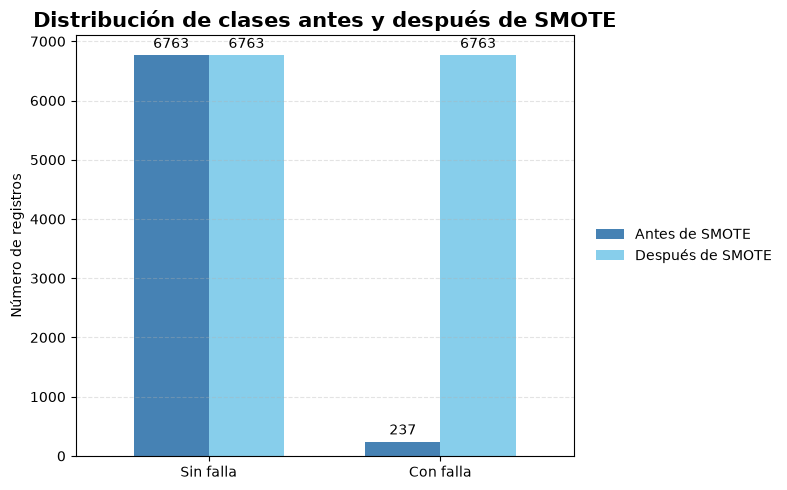

In [34]:
# Balanceo de clases mediante SMOTE

# Se aplica la técnica SMOTE únicamente sobre el conjunto de
# entrenamiento para equilibrar la cantidad de ejemplos de
# ambas clases antes del entrenamiento de los modelos.

smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train_scaled,
    y_train
)

# Comparar la distribución de clases antes y después de SMOTE
balance = pd.DataFrame({
    "Antes de SMOTE": y_train.value_counts().sort_index(),
    "Después de SMOTE": y_train_balanced.value_counts().sort_index()
})

balance.index = ["Sin falla", "Con falla"]

print("Distribución de clases antes y después de aplicar SMOTE:\n")
display(balance)

# ==========================================================
# Visualización del balance de clases
# ==========================================================

fig, ax = plt.subplots(figsize=(8, 5))

balance.plot(
    kind="bar",
    ax=ax,
    color=["steelblue", "skyblue"],
    width=0.65
)

# Agregar etiquetas con la cantidad de registros
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)

plt.title(
    "Distribución de clases antes y después de SMOTE",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("")
plt.ylabel("Número de registros")

plt.xticks(rotation=0)

# Cuadrícula para facilitar la lectura
plt.grid(axis="y", linestyle="--", alpha=0.35)

# Ubicar la leyenda fuera del gráfico
plt.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    title=""
)

plt.tight_layout()

plt.show()

**Interpretación**  

Antes de aplicar SMOTE, el conjunto de entrenamiento presentaba un marcado desbalance entre las clases, con **6.763 registros correspondientes a máquinas sin falla** y solo **237 registros de máquinas con falla**. Esta diferencia podía provocar que los modelos de aprendizaje automático aprendieran a favorecer la clase mayoritaria, reduciendo su capacidad para detectar fallas reales.

Tras aplicar la técnica **SMOTE**, la clase minoritaria fue balanceada mediante la generación de ejemplos sintéticos, obteniendo **6.763 registros para cada clase**. De esta manera, el conjunto de entrenamiento quedó completamente equilibrado, permitiendo que los modelos aprendan de forma más representativa ambas categorías y mejorando su capacidad para identificar eventos de falla.

Es importante destacar que SMOTE fue aplicado **únicamente sobre el conjunto de entrenamiento**, mientras que el conjunto de prueba se mantuvo sin modificaciones para evitar la fuga de información (*Data Leakage*) y garantizar una evaluación objetiva del desempeño de los modelos.

## 7. Entrenamiento de modelos

En esta etapa se entrenan los modelos de aprendizaje automático seleccionados para predecir la ocurrencia de fallas en las máquinas.

Con el fin de realizar una comparación objetiva, todos los modelos utilizan el mismo conjunto de entrenamiento previamente balanceado mediante SMOTE. Posteriormente, cada modelo genera predicciones sobre el conjunto de prueba, las cuales serán evaluadas utilizando distintas métricas de desempeño en la siguiente sección.

Los algoritmos considerados son:

- Random Forest
- XGBoost
- Perceptrón Multicapa (MLP)

### 7.1 Random Forest

In [35]:
# Entrenamiento del modelo Random Forest

# Se entrena un bosque aleatorio utilizando el conjunto
# de entrenamiento previamente balanceado con SMOTE.

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(
    X_train_balanced,
    y_train_balanced
)

# Predicciones sobre el conjunto de prueba
y_pred_rf = rf_model.predict(X_test_scaled)

print("Modelo Random Forest entrenado correctamente.")

Modelo Random Forest entrenado correctamente.


### 7.2 XGBoost

In [36]:
# Entrenamiento del modelo XGBoost

# Se entrena un modelo basado en Gradient Boosting
# optimizado para tareas de clasificación.

xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(
    X_train_balanced,
    y_train_balanced
)

# Predicciones sobre el conjunto de prueba
y_pred_xgb = xgb_model.predict(X_test_scaled)

print("Modelo XGBoost entrenado correctamente.")

Modelo XGBoost entrenado correctamente.


### 7.3 Perceptrón Multicapa (MLP)

In [37]:
# Entrenamiento del modelo Perceptrón Multicapa

# Se entrena una red neuronal artificial de tres capas
# ocultas utilizando el conjunto balanceado.

mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32, 16),
    activation="relu",
    solver="adam",
    max_iter=500,
    random_state=42
)

mlp_model.fit(
    X_train_balanced,
    y_train_balanced
)

# Predicciones sobre el conjunto de prueba
y_pred_mlp = mlp_model.predict(X_test_scaled)

print("Modelo MLP entrenado correctamente.")

Modelo MLP entrenado correctamente.


**Resumen de la etapa**

Los tres modelos seleccionados fueron entrenados exitosamente utilizando el mismo conjunto de entrenamiento previamente balanceado mediante SMOTE. Cada uno generó predicciones sobre el conjunto de prueba, las cuales serán evaluadas en la siguiente sección utilizando distintas métricas de desempeño para identificar el modelo con mejor capacidad predictiva.

## 8. Evaluación de modelos

Una vez entrenados los modelos, se evalúa su desempeño utilizando el conjunto de prueba, el cual no participó durante el entrenamiento ni en el balanceo mediante SMOTE.

Para cada algoritmo se analizan métricas de clasificación como **precisión (Precision)**, **exhaustividad (Recall)**, **F1-Score**, **Accuracy** y el **Área Bajo la Curva ROC (AUC-ROC)**. Estas métricas permiten comparar objetivamente el rendimiento de los modelos y seleccionar el más adecuado para la predicción de fallas.

### 8.1 Reportes de clasificación

En esta sección se presentan los reportes de clasificación obtenidos para cada modelo. Estos reportes muestran el desempeño individual sobre cada clase mediante las métricas de **Precision**, **Recall**, **F1-Score** y **Accuracy**, permitiendo realizar una primera comparación entre los algoritmos entrenados.

In [38]:
# Reportes de clasificación

# Función para mostrar el desempeño de cada modelo mediante
# el Classification Report y el AUC-ROC.

def evaluar_modelo(y_real, y_pred, nombre_modelo):

    print("=" * 60)
    print(f"{nombre_modelo}")
    print("=" * 60)

    print(classification_report(y_real, y_pred))

    auc = roc_auc_score(y_real, y_pred)

    print(f"AUC-ROC: {auc:.4f}\n")


# Evaluación de los modelos
evaluar_modelo(y_test, y_pred_rf, "Random Forest")

evaluar_modelo(y_test, y_pred_xgb, "XGBoost")

evaluar_modelo(y_test, y_pred_mlp, "Perceptrón Multicapa (MLP)")

Random Forest
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      2898
           1       0.47      0.72      0.57       102

    accuracy                           0.96      3000
   macro avg       0.73      0.84      0.77      3000
weighted avg       0.97      0.96      0.97      3000

AUC-ROC: 0.8435

XGBoost
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      2898
           1       0.61      0.77      0.68       102

    accuracy                           0.98      3000
   macro avg       0.80      0.88      0.83      3000
weighted avg       0.98      0.98      0.98      3000

AUC-ROC: 0.8785

Perceptrón Multicapa (MLP)
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      2898
           1       0.50      0.73      0.59       102

    accuracy                           0.97      3000
   macro avg       0.75      0.85      0.79  

**Interpretación**

Los reportes de clasificación muestran que los tres modelos fueron capaces de identificar correctamente la mayoría de los registros correspondientes a máquinas sin falla, obteniendo valores elevados de precisión y desempeño general.

Sin embargo, las diferencias más relevantes se observan en la detección de la clase minoritaria (máquinas con falla). En este aspecto, **XGBoost** obtuvo el mejor equilibrio entre precisión, recall y F1-Score, logrando identificar una mayor proporción de fallas respecto a los demás modelos. Por su parte, el **Perceptrón Multicapa (MLP)** presentó un rendimiento intermedio, mientras que **Random Forest** obtuvo el menor desempeño para esta clase.

Estos resultados permiten realizar una primera comparación entre los modelos, la cual será complementada en la siguiente sección mediante una tabla comparativa de métricas para seleccionar el algoritmo con mejor desempeño.

### 8.2 Comparación de métricas de desempeño

Con el objetivo de facilitar la comparación entre los modelos entrenados, se resumen las principales métricas de evaluación en una única tabla. Se consideran **Accuracy**, **Precision**, **Recall**, **F1-Score** y **AUC-ROC**, las cuales permiten evaluar tanto el desempeño general como la capacidad de cada algoritmo para detectar correctamente las fallas de las máquinas.

Esta comparación facilita la selección del modelo con mejor rendimiento para las etapas posteriores de análisis e interpretación.

In [ ]:
# Comparación de métricas de desempeño

# Se construye una tabla comparativa con las principales
# métricas obtenidas por cada modelo.

comparacion = pd.DataFrame({
    "Accuracy": [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_mlp)
    ],
    "Precision": [
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_mlp)
    ],
    "Recall": [
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_mlp)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_mlp)
    ],
    "AUC-ROC": [
        roc_auc_score(y_test, y_pred_rf),
        roc_auc_score(y_test, y_pred_xgb),
        roc_auc_score(y_test, y_pred_mlp)
    ]
},
index=[
    "Random Forest",
    "XGBoost",
    "Perceptrón Multicapa"
])

# Redondear los resultados para facilitar la lectura
comparacion = comparacion.round(4)

display(comparacion)

,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Random Forest,0.9627,0.4679,0.7157,0.5659,0.8435
XGBoost,0.9753,0.6077,0.7745,0.6810,0.8785
Perceptrón Multicapa,0.9660,0.5000,0.7255,0.5920,0.8500


**Interpretación**

La comparación de métricas muestra que los tres modelos obtuvieron un buen desempeño general al clasificar el estado de las máquinas. Sin embargo, existen diferencias importantes en la detección de la clase minoritaria (máquinas con falla).

El modelo **XGBoost** obtuvo los mejores resultados en la mayoría de las métricas evaluadas, alcanzando el mayor **Accuracy (97.53%)**, **Precision (60.77%)**, **Recall (77.45%)**, **F1-Score (68.10%)** y **AUC-ROC (0.8785)**. Esto indica que fue el algoritmo con mejor capacidad para identificar correctamente las fallas, manteniendo al mismo tiempo un buen equilibrio entre precisión y sensibilidad.

El **Perceptrón Multicapa (MLP)** presentó un desempeño intermedio, superando ligeramente a **Random Forest** en Recall, F1-Score y AUC-ROC. Por su parte, **Random Forest** obtuvo los resultados más bajos en la mayoría de las métricas, aunque igualmente mostró un desempeño adecuado para la clasificación de la clase mayoritaria.

Considerando estos resultados, **XGBoost se selecciona como el modelo con mejor desempeño**, por lo que será utilizado en las siguientes etapas del proyecto para un análisis más detallado mediante la matriz de confusión, la curva ROC y la interpretación con SHAP.

### 8.3 Matriz de confusión

La matriz de confusión permite analizar con mayor detalle el desempeño del modelo seleccionado, mostrando la cantidad de predicciones correctas e incorrectas para cada una de las clases.

Esta representación facilita identificar los verdaderos positivos, verdaderos negativos, falsos positivos y falsos negativos, permitiendo evaluar la capacidad del modelo para detectar fallas en las máquinas.

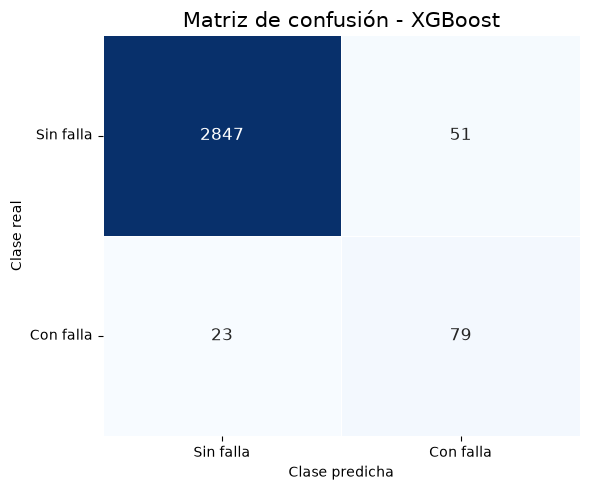

In [41]:
# Matriz de confusión

# Se genera la matriz de confusión del modelo XGBoost,
# seleccionado como el mejor modelo según las métricas
# obtenidas en la etapa de evaluación.

cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    linewidths=0.5,
    annot_kws={"size":12}
)

plt.title("Matriz de confusión - XGBoost", fontsize=15)
plt.xlabel("Clase predicha")
plt.ylabel("Clase real")

plt.xticks(
    [0.5,1.5],
    ["Sin falla","Con falla"]
)

plt.yticks(
    [0.5,1.5],
    ["Sin falla","Con falla"],
    rotation=0
)

plt.tight_layout()

plt.show()

**Interpretación**

La matriz de confusión muestra que el modelo **XGBoost** logró clasificar correctamente la gran mayoría de los registros del conjunto de prueba.

Se identificaron correctamente **2847 máquinas sin falla** y **79 máquinas con falla**, mientras que únicamente **51 máquinas sin falla fueron clasificadas incorrectamente como falladas (falsos positivos)** y **23 máquinas con falla no fueron detectadas (falsos negativos)**.

Estos resultados evidencian que el modelo presenta una alta capacidad para distinguir entre ambas clases, manteniendo un número reducido de errores. Además, el bajo número de falsos negativos es especialmente importante en un problema de mantenimiento predictivo, ya que permite reducir el riesgo de que una máquina con una falla real pase inadvertida.

En conjunto, la matriz de confusión confirma el buen desempeño observado previamente en las métricas de evaluación y respalda la selección de **XGBoost** como el modelo con mejor rendimiento para este problema.

### 8.4 Curvas ROC y comparación del AUC

La curva ROC (Receiver Operating Characteristic) permite evaluar la capacidad de un modelo para distinguir entre las clases "con falla" y "sin falla" bajo diferentes umbrales de decisión.

El Área Bajo la Curva (AUC-ROC) resume este comportamiento en un único valor comprendido entre 0 y 1. Mientras más cercano sea a 1, mejor será la capacidad del modelo para discriminar correctamente entre ambas clases.

En esta sección se comparan las curvas ROC obtenidas por los tres modelos entrenados.

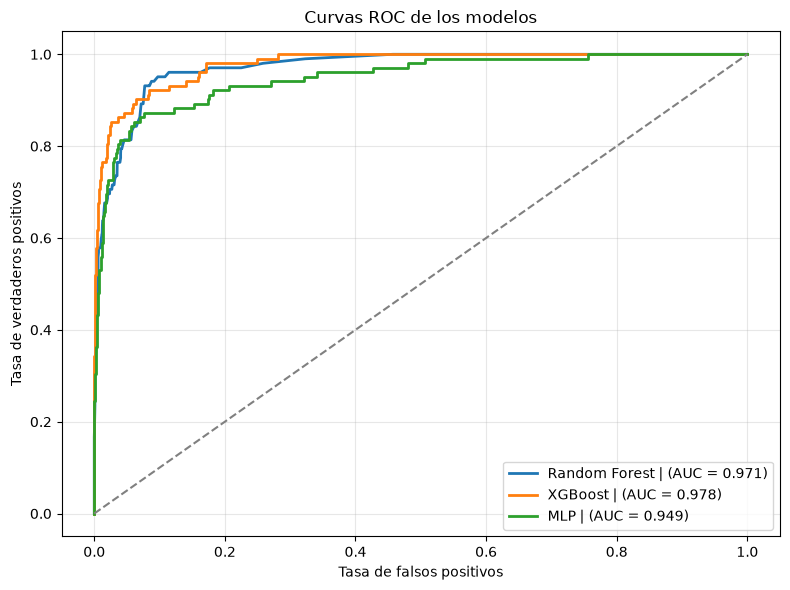

In [43]:
# Curvas ROC

# Se comparan las curvas ROC de los tres modelos utilizando
# las probabilidades estimadas para la clase positiva.

from sklearn.metrics import roc_curve

# Obtener probabilidades de la clase positiva
rf_prob = rf_model.predict_proba(X_test_scaled)[:, 1]
xgb_prob = xgb_model.predict_proba(X_test_scaled)[:, 1]
mlp_prob = mlp_model.predict_proba(X_test_scaled)[:, 1]

# Calcular curvas ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_prob)
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, mlp_prob)

# Calcular AUC utilizando probabilidades
auc_rf = roc_auc_score(y_test, rf_prob)
auc_xgb = roc_auc_score(y_test, xgb_prob)
auc_mlp = roc_auc_score(y_test, mlp_prob)

# Graficar curvas ROC
plt.figure(figsize=(8,6))

plt.plot(
    fpr_rf,
    tpr_rf,
    linewidth=2,
    label=f"Random Forest | (AUC = {auc_rf:.3f})"
)

plt.plot(
    fpr_xgb,
    tpr_xgb,
    linewidth=2,
    label=f"XGBoost | (AUC = {auc_xgb:.3f})"
)

plt.plot(
    fpr_mlp,
    tpr_mlp,
    linewidth=2,
    label=f"MLP | (AUC = {auc_mlp:.3f})"
)

# Línea de referencia
plt.plot([0,1], [0,1], linestyle="--", color="gray")

plt.title("Curvas ROC de los modelos")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")

plt.legend(loc="lower right")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

**Interpretación**

Las curvas ROC muestran que los tres modelos presentan una buena capacidad para diferenciar entre máquinas con falla y sin falla, ya que sus curvas se mantienen muy por encima de la línea diagonal de referencia, la cual representa una clasificación aleatoria.

El modelo **XGBoost** obtuvo el mayor **AUC-ROC (0.978)**, lo que indica la mejor capacidad discriminativa entre las clases. En segundo lugar se ubicó **Random Forest**, con un **AUC de 0.971**, mientras que el **Perceptrón Multicapa (MLP)** alcanzó un **AUC de 0.949**.

Aunque los tres modelos presentan un desempeño elevado, **XGBoost** mantiene una ligera ventaja durante la mayor parte de la curva ROC, confirmando los resultados obtenidos anteriormente mediante las métricas de evaluación y la matriz de confusión.

Estos resultados respaldan la selección de **XGBoost** como el modelo más adecuado para el problema de mantenimiento predictivo abordado en este proyecto.

### 8.5 Selección del mejor modelo

A partir de las métricas de evaluación, la matriz de confusión y las curvas ROC, se selecciona el modelo con mejor desempeño para el problema de clasificación de fallas.

Esta selección se fundamenta en una comparación objetiva de los resultados obtenidos por cada algoritmo, considerando tanto el desempeño general como la capacidad para detectar correctamente la clase minoritaria correspondiente a las máquinas con falla.

In [44]:
# Selección del mejor modelo

# Se registra el modelo con mejor desempeño obtenido durante
# la etapa de evaluación para utilizarlo en el análisis de
# interpretabilidad mediante SHAP.

mejor_modelo = xgb_model

print("Modelo seleccionado para la etapa de interpretación:")
print("XGBoost")

Modelo seleccionado para la etapa de interpretación:
XGBoost


**Interpretación**

Considerando los resultados obtenidos durante la evaluación, **XGBoost** fue seleccionado como el modelo con mejor desempeño para este proyecto.

Este algoritmo obtuvo los mejores resultados en las principales métricas de clasificación, incluyendo **Accuracy**, **Precision**, **Recall** y **F1-Score**, además de presentar la mayor capacidad discriminativa en la curva ROC. Asimismo, la matriz de confusión evidenció un número reducido de errores de clasificación, especialmente en la detección de máquinas con falla.

Por estas razones, **XGBoost** fue elegido para la etapa de interpretación mediante SHAP, con el objetivo de analizar qué variables influyen en las decisiones tomadas por el modelo.

## 9. Interpretabilidad del modelo mediante SHAP

La interpretación de modelos es una etapa fundamental en proyectos de Machine Learning, permite comprender cómo las variables influyen en las predicciones realizadas por el algoritmo.

En este proyecto se utiliza la librería **SHAP (SHapley Additive exPlanations)** para analizar el modelo seleccionado (XGBoost), identificando las variables con mayor impacto en la predicción de fallas de maquinaria.

Este análisis aporta transparencia al modelo y facilita la comprensión de las decisiones tomadas durante el proceso de clasificación.

### 9.1 Inicialización de SHAP

En esta sección se inicializa la librería SHAP y se prepara el conjunto de datos de prueba para generar las explicaciones del modelo XGBoost.

Debido a que SHAP conserva los nombres de las variables para mostrar resultados más interpretables, el conjunto de prueba escalado se convierte nuevamente en un DataFrame antes de calcular los valores SHAP.

In [45]:
# Inicialización de SHAP

# Se prepara el modelo XGBoost para realizar el análisis
# de interpretabilidad mediante SHAP.

# Inicializar SHAP
shap.initjs()

# Crear el explicador para el modelo XGBoost
explainer = shap.TreeExplainer(xgb_model)

# Convertir el conjunto de prueba escalado nuevamente
# en un DataFrame para conservar los nombres originales
# de las variables.
X_test_df = pd.DataFrame(
    X_test_scaled,
    columns=X.columns
)

print("Conjunto preparado para el análisis SHAP:")
display(X_test_df.head())

Conjunto preparado para el análisis SHAP:


,Air_temperature_K,Process_temperature_K,Rotational_speed_rpm,Torque_Nm,Tool_wear_min,Type_L,Type_M
0,-0.007169,0.940494,-0.012415,-0.459886,0.193808,-1.230964,1.539033
1,-1.405400,-1.219433,0.769942,-1.189500,0.397380,-1.230964,1.539033
2,0.192578,-0.206967,0.808783,-0.769722,0.929800,-1.230964,1.539033
3,-0.156980,-0.544456,-0.461854,0.059838,1.164691,-1.230964,-0.649758
4,0.342388,0.738001,0.825429,-0.929637,0.835844,0.812372,-0.649758


**Interpretación**

La librería SHAP fue inicializada correctamente y el conjunto de prueba quedó preparado para el análisis de interpretabilidad del modelo XGBoost.

La conversión del conjunto de datos escalado a un DataFrame permitió conservar los nombres de las variables predictoras, facilitando la identificación de cada característica durante la generación de las explicaciones del modelo.

Esta preparación es un paso previo necesario para calcular la contribución individual de cada variable en las predicciones realizadas por el modelo seleccionado.

### 9.2 Importancia global de las variables

En esta sección se calculan los valores SHAP del modelo XGBoost para analizar la influencia de cada variable predictora sobre las decisiones del algoritmo.

Posteriormente se genera un gráfico resumen (*SHAP Summary Plot*), el cual permite visualizar tanto la importancia relativa de cada variable como el efecto que tienen sus diferentes valores sobre la probabilidad de que ocurra una falla en la maquinaria.

Calculando valores SHAP...
Generando gráfico resumen de SHAP...


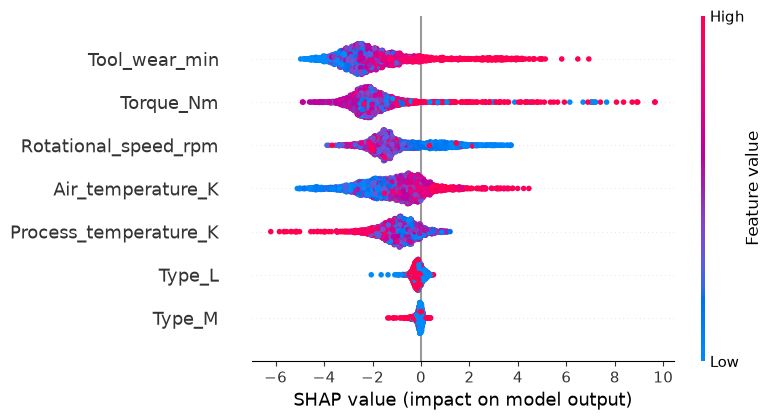

In [46]:
# Importancia global de las variables con SHAP

# Se calculan los valores SHAP para conocer la contribución
# de cada variable en las predicciones realizadas por
# el modelo XGBoost.

print("Calculando valores SHAP...")

# Calcular valores SHAP
shap_values = explainer.shap_values(X_test_df)

print("Generando gráfico resumen de SHAP...")

# Gráfico de importancia global
shap.summary_plot(
    shap_values,
    X_test_df,
    show=True
)

**Interpretación:**

El gráfico SHAP muestra la importancia global de las variables utilizadas por el modelo XGBoost para predecir fallas en la maquinaria.

La variable con mayor influencia es **Tool_wear_min**, indicando que el desgaste de la herramienta es el factor que más contribuye a las decisiones del modelo. En segundo lugar se encuentra **Torque_Nm**, seguido por **Rotational_speed_rpm**, evidenciando que las variables relacionadas con el funcionamiento mecánico tienen un papel predominante en la predicción de fallas.

Las variables **Air_temperature_K** y **Process_temperature_K** también influyen en las predicciones, aunque con un impacto menor. Por otra parte, las variables categóricas **Type_L** y **Type_M** presentan una contribución reducida, por lo que el tipo de producto tiene poca influencia en comparación con las variables operacionales.

En general, el análisis SHAP confirma que el modelo basa principalmente sus decisiones en características directamente relacionadas con el estado de operación de la máquina, lo que resulta consistente con el problema de mantenimiento predictivo abordado en este proyecto.

## 10. Conclusiones

Se desarrolló un flujo completo de aprendizaje automático para la predicción de fallas industriales utilizando el dataset AI4I 2020.

Durante el proceso se realizó el análisis exploratorio de los datos, la limpieza y preprocesamiento, el balanceo de clases mediante SMOTE, el entrenamiento de tres modelos supervisados y su evaluación mediante distintas métricas.

Los resultados obtenidos muestran que XGBoost alcanzó el mejor desempeño general, destacando principalmente en F1-Score y ROC-AUC para la detección de fallas.

Finalmente, mediante SHAP fue posible interpretar el comportamiento del modelo, identificando que variables como el desgaste de la herramienta (Tool Wear), el torque y la velocidad de rotación son las que más influyen en las predicciones.